<h1 style="text-align: center;">Task-2C</h1>
<h3 style="text-align: right;">Name: Yatharth Deoly</h3>
<h3 style="text-align: right;">StudentId: 224207854</h3>
<h3 style="text-align: right;">EmailId: yatharthdeoly@gmail.com</h3>


## Introduction

In this task, we will be working with 2 different datasets, i.e. Obesity and Gene datasets.
Here we will be using kmeans(random, kmeans++) and DBSCAN for clustering mechanism and PCA for dimensionality reduction.

### Obesity dataset

This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. The data contains 17 attributes and 2111 records, the records are labeled with the class variable NObesity (Obesity Level), that allows classification of the data using the values of Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II and Obesity Type III. 77% of the data was generated synthetically using the Weka tool and the SMOTE filter, 23% of the data was collected directly from users through a web platform.

Explaining features and targets:

- FEATURES
  - Gender -> categorical type
  - Age -> Continuous type
  - Height -> Continuous type
  - Weight -> Continuous type
  - family_history_with_overweight -> Has a family member suffered or suffers from overweight? (Binary type)
  - FAVC -> Do you eat high caloric food frequently? (Binary type)
  - FCVC -> Do you usually eat vegetables in your meals? (Integer type)
  - NCP -> How many main meals do you have daily? (Continuous type)
  - CAEC -> Do you eat any food between meals? (Categorical type)
  - SMOKE -> Do you smoke? (Binary type)
  - CH2O -> How much water do you drink daily? (Continuous type)
  - SCC -> Do you monitor the calories you eat daily? (Binary type)
  - FAF -> How often do you have physical activity? (Continuous type)
  - TUE -> How much time do you use technological devices such as cell phone, videogames, television, computer and others? (Integer type)
  - CALC -> How often do you drink alcohol? (Categorical type)
  - MTRANS -> Which transportation do you usually use? (Category type)
- TARGET
  - NObeyesdad -> Obesity level (Category type)

### Gene dataset

This collection of data is part of the RNA-Seq (HiSeq) PANCAN data set, it is a random extraction of gene expressions of patients having different types of tumor: BRCA, KIRC, COAD, LUAD and PRAD.


Defining imports at the top that will be used by the report.
In this case, having all the imports at the top is more intuitive than having some of them at the top and some of them scattered over the file.


In [1]:
import pandas as pd
import numpy as np

import warnings

# Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.
import matplotlib.pyplot as plt

import plotly.express as px

# Ignore all warnings generated by the Python program
warnings.filterwarnings("ignore")

# This command tells the IPython environment to draw the plots immediately after the current cell
%matplotlib inline

from sklearn.preprocessing import LabelEncoder, StandardScaler, MaxAbsScaler

# MaxAbsScaler
maxabs_scaler = MaxAbsScaler()

# Initialize the label encoder
label_encoder = LabelEncoder()

# Apply min-max scaling
scaler = StandardScaler() 

from sklearn.cluster import DBSCAN

from sklearn.neighbors import NearestNeighbors

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score

from kneed import KneeLocator

from sklearn.feature_selection import VarianceThreshold


random_state = 42

Extracting data into pandas Dataframe from a file.


In [2]:
obesity_df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

# Printing random 5 data from our dataframe
obesity_df.sample(n=5, random_state=random_state)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
544,Female,20.406871,1.755978,53.699561,yes,yes,2.0,3.891994,Frequently,no,1.863930,no,2.870127,2.000000,no,Public_Transportation,Insufficient_Weight
1987,Female,26.000000,1.624950,111.004920,yes,yes,3.0,3.000000,Sometimes,no,2.704315,no,0.000000,0.322666,Sometimes,Public_Transportation,Obesity_Type_III
420,Male,18.000000,1.850000,60.000000,yes,yes,3.0,4.000000,Sometimes,no,2.000000,yes,2.000000,0.000000,Sometimes,Automobile,Insufficient_Weight
527,Female,21.000000,1.520000,42.000000,no,yes,3.0,1.000000,Frequently,no,1.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Insufficient_Weight
196,Male,22.000000,1.750000,74.000000,yes,no,2.0,3.000000,Sometimes,no,2.000000,no,1.000000,2.000000,Sometimes,Bike,Normal_Weight


In [3]:
print(
    f"Estimation of Obesity Levels Based On Eating Habits and Physical Condition dataset have {
        obesity_df.shape[0]} entries for {obesity_df.shape[1]} features."
)

Estimation of Obesity Levels Based On Eating Habits and Physical Condition dataset have 2111 entries for 17 features.


In [4]:
# Backing-up the dataset for future usage as we will be performing EDA/pre-processing on it.
obesity_df_backup = obesity_df.copy(deep=True)

In [5]:
# Check for missing values
obesity_df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [6]:
# Checking duplicates in the dataset
obesity_df.duplicated().sum()

24

In [7]:
# Removing duplicated rows from the dataset
obesity_df.drop_duplicates(inplace=True)

# check if there is any remaining duplicated values
obesity_df.duplicated().sum()

0

Understanding features relation with target varible i.e. NObeyesdad(Obesity level)

- Demographic and physical attributes: Gender, age, height, weight are directly related to obesity and can be used as numerical features.
- Lifestyle factors: Family history, eating habits (FAVC, FCVC, NCP, CAEC), smoking (SMOKE), physical activity (FAF), alcohol consumption (CALC), and technology usage (TUE) can influence obesity and are suitable for clustering.
- Behavioral factors: Water consumption (CH2O) and calorie monitoring (SCC) might indirectly relate to obesity but can be excluded for exploration.
- MTRANS (mode of transportation) might not have a direct impact on obesity and can be excluded for exploration.

So currently will be checking via VarianceThreshold method with threshold as 0.1 and will take that as ground realtiy for our feature elimination before excluding CH2O, SCC and MTRANS.


In [8]:
# Dropping features which are not required for analysis
obesity_df.drop(columns=['CH2O', 'SCC', 'MTRANS'], inplace=True)

# One-hot encoding for nominal categorical features
columns_to_encode = [
    'Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE']
obesity_df = pd.get_dummies(obesity_df, columns=columns_to_encode, dtype=int)


# Label encoding for ordinal categorical features
obesity_df['CAEC'] = label_encoder.fit_transform(obesity_df['CAEC'].to_numpy())
obesity_df['CALC'] = label_encoder.fit_transform(obesity_df['CALC'].to_numpy())
obesity_df['NObeyesdad'] = label_encoder.fit_transform(
    obesity_df['NObeyesdad'].to_numpy())


# Apply VarianceThreshold
selector = VarianceThreshold(threshold=0.1)
selector.fit_transform(obesity_df)

# Get the retained features
retained_features = obesity_df.columns[selector.get_support(indices=True)]
retained_features

Index(['Age', 'Weight', 'FCVC', 'NCP', 'CAEC', 'FAF', 'TUE', 'CALC',
       'NObeyesdad', 'Gender_Female', 'Gender_Male',
       'family_history_with_overweight_no',
       'family_history_with_overweight_yes', 'FAVC_no', 'FAVC_yes'],
      dtype='object')

In [9]:
obesity_df = obesity_df[retained_features]
obesity_df.head()

,Age,Weight,FCVC,NCP,CAEC,FAF,TUE,CALC,NObeyesdad,Gender_Female,Gender_Male,family_history_with_overweight_no,family_history_with_overweight_yes,FAVC_no,FAVC_yes
0,21.0,64.0,2.0,3.0,2,0.0,1.0,3,1,1,0,0,1,1,0
1,21.0,56.0,3.0,3.0,2,3.0,0.0,2,1,1,0,0,1,1,0
2,23.0,77.0,2.0,3.0,2,2.0,1.0,1,1,0,1,0,1,1,0
3,27.0,87.0,3.0,3.0,2,2.0,0.0,1,5,0,1,1,0,1,0
4,22.0,89.8,2.0,1.0,2,0.0,0.0,2,6,0,1,1,0,1,0


In [10]:
# Bifrucating feature and target
X = obesity_df.drop(columns="NObeyesdad", axis=1)
y = obesity_df["NObeyesdad"]

X_scaled = maxabs_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled

,Age,Weight,FCVC,NCP,CAEC,FAF,TUE,CALC,Gender_Female,Gender_Male,family_history_with_overweight_no,family_history_with_overweight_yes,FAVC_no,FAVC_yes
0,0.344262,0.369942,0.666667,0.75,0.666667,0.000000,0.500000,1.000000,1.0,0.0,0.0,1.0,1.0,0.0
1,0.344262,0.323699,1.000000,0.75,0.666667,1.000000,0.000000,0.666667,1.0,0.0,0.0,1.0,1.0,0.0
2,0.377049,0.445087,0.666667,0.75,0.666667,0.666667,0.500000,0.333333,0.0,1.0,0.0,1.0,1.0,0.0
3,0.442623,0.502890,1.000000,0.75,0.666667,0.666667,0.000000,0.333333,0.0,1.0,1.0,0.0,1.0,0.0
4,0.360656,0.519075,0.666667,0.25,0.666667,0.000000,0.000000,0.666667,0.0,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0.343883,0.759587,1.000000,0.75,0.666667,0.558756,0.453124,0.666667,1.0,0.0,0.0,1.0,0.0,1.0
2083,0.360376,0.773081,1.000000,0.75,0.666667,0.447130,0.299635,0.666667,1.0,0.0,0.0,1.0,0.0,1.0
2084,0.369246,0.772771,1.000000,0.75,0.666667,0.471403,0.323144,0.666667,1.0,0.0,0.0,1.0,0.0,1.0
2085,0.399376,0.770790,1.000000,0.75,0.666667,0.379702,0.293017,0.666667,1.0,0.0,0.0,1.0,0.0,1.0


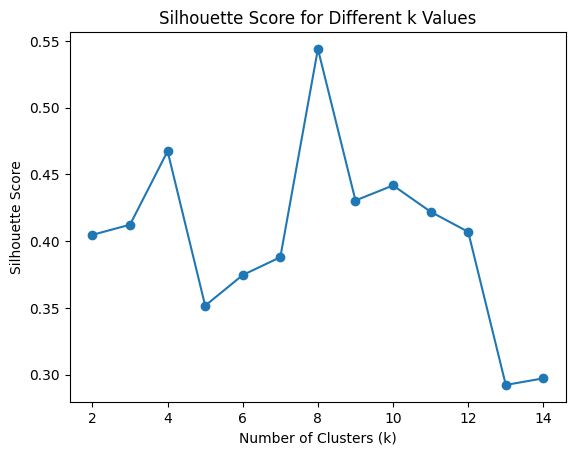

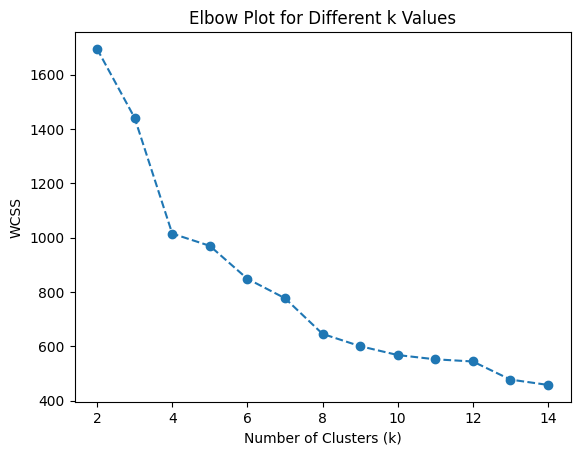

The optimal k value is: 8


In [11]:
# Determine the optimal k value using silhouette score
silhouette_scores = []
wcss = []
k_values = range(2, 15)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    wcss.append(kmeans.inertia_)

# Plot the silhouette scores
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k Values")
plt.show()

# Plot the Elbow plot
plt.plot(k_values, wcss, "o--")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Plot for Different k Values")
plt.show()

# Optimum k value
optimal_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f'The optimal k value is: {optimal_k}')

Optimal value of k has been derived as 8, which will be used for further analysis.


In [12]:
# Create clusters using KMeans
kmeans = KMeans(n_clusters=optimal_k, init="random", random_state=random_state)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Create clusters using KMeans++
kmeans_pp = KMeans(n_clusters=optimal_k, init="k-means++",
                   random_state=random_state)
kmeans_pp_labels = kmeans_pp.fit_predict(X_scaled)

# Davies-Bouldin Score
dbs_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
dbs_kmeans_pp = davies_bouldin_score(X_scaled, kmeans_pp_labels)

# Silhouette Score
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
silhouette_kmeans_pp = silhouette_score(X_scaled, kmeans_pp_labels)

print(f"Silhouette Score for KMeans: {silhouette_kmeans}")
print(f"Silhouette Score for KMeans++: {silhouette_kmeans_pp}")
print(f"Davies-Bouldin Score for KMeans: {dbs_kmeans}")
print(f"Davies-Bouldin Score for KMeans++: {dbs_kmeans_pp}")

Silhouette Score for KMeans: 0.2733965348413056
Silhouette Score for KMeans++: 0.5441247197428557
Davies-Bouldin Score for KMeans: 1.375268376427906
Davies-Bouldin Score for KMeans++: 0.8163681920655886


- Silhouette Score: 
    - KMeans: 0.2734
    - KMeans++: 0.5441
    
    A higher Silhouette Score indicates better-defined clusters. KMeans++ has a significantly higher Silhouette Score compared to KMeans, indicating that KMeans++ achieves better cluster cohesion and separation.
- Davies-Bouldin Score:
    - KMeans: 1.3753
    - KMeans++: 0.8164
    
    A lower Davies-Bouldin Score indicates better clustering performance in terms of cluster compactness and separation. KMeans++ has a notably lower Davies-Bouldin Score compared to KMeans, suggesting that KMeans++ produces more compact and well-separated clusters.

Conclusion

- KMeans++ outperforms KMeans in terms of both Silhouette Score and Davies-Bouldin Score.
- KMeans++ provides better-defined clusters with higher cohesion and separation.
- KMeans++ results in clusters that are more compact and better separated.


In [13]:
# Repeat clustering 50 times and report average performance for KMeans
kmeans_dbs_scores = []
kmeans_sil_scores = []

for _ in range(50):
    kmeans = KMeans(n_clusters=optimal_k,
                    random_state=random_state, init="random")
    kmeans_labels = kmeans.fit_predict(X_scaled)
    kmeans_dbs_scores.append(davies_bouldin_score(X_scaled, kmeans_labels))
    kmeans_sil_scores.append(silhouette_score(X_scaled, kmeans_labels))

print(
    f"Average Davies-Bouldin Score for KMeans over 50 runs: {
        np.mean(kmeans_dbs_scores)}"
)
print(f"Average Silhouette Score for KMeans over 50 runs: {
      np.mean(kmeans_sil_scores)}")

Average Davies-Bouldin Score for KMeans over 50 runs: 1.3752683764279061
Average Silhouette Score for KMeans over 50 runs: 0.2733965348413056


Analysis

- Silhouette Score:
    - Avg KMeans (over 50 runs): 0.2733
    - KMeans++: 0.5441
    
    The KMeans++ algorithm provides a much higher Silhouette Score in a single run compared to the average score of KMeans over 50 runs. This indicates that KMeans++ is more effective in creating well-separated clusters.

- Davies-Bouldin Score:
    - Avg KMeans (over 50 runs): 1.3752
    - KMeans++: 0.8164
    
    KMeans++ has a considerably lower Davies-Bouldin Score compared to the average score of KMeans over 50 runs, indicating that KMeans++ generally forms clusters that are more compact and well-separated.


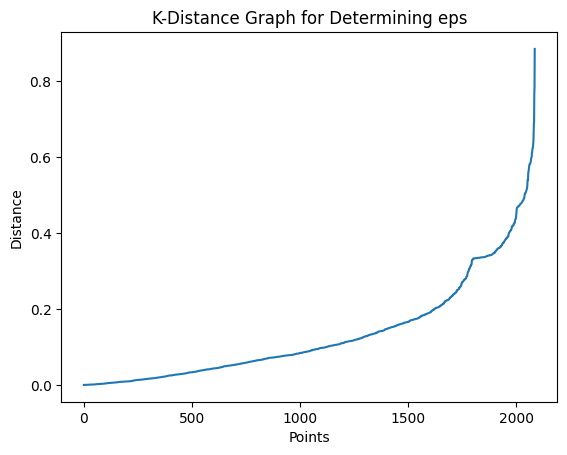

Optimal eps: 0.5406903312457536


In [14]:
# Determine the optimal eps value
nearest_neighbors = NearestNeighbors(n_neighbors=7)
neighbors = nearest_neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

distances = np.sort(distances[:, 1], axis=0)
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("Distance")
plt.title("K-Distance Graph for Determining eps")
plt.show()

# Using KneeLocator will be calculating "eps" value
kneedle = KneeLocator(range(len(distances)), distances,
                      S=1.0, curve="convex", direction="increasing")
optimal_eps = distances[kneedle.elbow]

print(f"Optimal eps: {optimal_eps}")

In [15]:
# Calculating the min_samples for DBSCAN
min_samples_range = range(2, X_scaled.shape[1])
silhouette_scores = []

for min_samples in min_samples_range:
    clustering = DBSCAN(eps=optimal_eps, min_samples=min_samples).fit(X_scaled)
    silhouette_score_value = silhouette_score(X_scaled, clustering.labels_)
    silhouette_scores.append((min_samples, silhouette_score_value))

best_min_samples, best_silhouette_score = max(
    silhouette_scores, key=lambda x: x[1])
print("Best min_samples:", best_min_samples)
print("Best silhouette score:", best_silhouette_score)

Best min_samples: 4
Best silhouette score: 0.5300722986793238


In [16]:
# Apply DBSCAN
dbscan = DBSCAN(eps=optimal_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

silhouette = silhouette_score(X_scaled, dbscan_labels)
dbs = davies_bouldin_score(X_scaled, dbscan_labels)

print(f"Silhouette Score: {silhouette}")
print(f"Davies-Bouldin Score: {dbs}")

# Number of clusters
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"Number of clusters found by DBSCAN: {n_clusters_dbscan}")

Silhouette Score: 0.5300722986793238
Davies-Bouldin Score: 1.5445984906820724
Number of clusters found by DBSCAN: 8


Analysis:

- KMeans with Silhouette Coefficient: The Silhouette Coefficient helps determine the optimum k by evaluating how well-separated the clusters are. This method indicated that 8 clusters provide the best separation and cohesion for the dataset.
- DBSCAN: This method identifies clusters based on density, which can result in a different number of clusters compared to methods like KMeans. In this case, DBSCAN also found 8 clusters, suggesting that the dataset has 8 distinct regions of density suitable for clustering.


Both KMeans (using the Silhouette Coefficient) and DBSCAN identified the same number of clusters (8) in the dataset. This indicates a strong consistency in the structure of the data, suggesting that both the separation and density-based approaches recognize similar patterns.

#### END OF OBESITY DATASET

#### START OF GENE DATASET


In [17]:
data_df = pd.read_csv("data.csv")
data_df.shape

(801, 20532)

In [18]:
label_df = pd.read_csv("labels.csv")
label_df.shape

(801, 2)

In [19]:
gene_df = pd.merge(
    data_df, label_df, left_on=data_df.columns[0], right_on=label_df.columns[0]
)
gene_df.rename(columns={gene_df.columns[0]: "sample"}, inplace=True)
gene_df.shape

(801, 20533)

In [20]:
gene_df.head()

,sample,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [21]:
print(
    f"Gene expression cancer RNA-Seq dataset have {
        gene_df.shape[0]} entries for {gene_df.shape[1]} features."
)

Gene expression cancer RNA-Seq dataset have 801 entries for 20533 features.


### PRE-PROCESSING


In [22]:
# Dropping missing or duplicate points
gene_df.dropna(inplace=True)
gene_df.drop_duplicates(inplace=True)

data = gene_df.drop(columns=["sample", "Class"])

# Calculate the IQR for each feature
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
is_outlier = (data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))

# Replace outliers with the median
median_values = data.median()
data_no_outliers = data.mask(is_outlier, median_values, axis=1)

gene_df_scaled = scaler.fit_transform(data_no_outliers)
gene_df_scaled = pd.DataFrame(gene_df_scaled, columns=data_no_outliers.columns)

In [23]:
gene_df_scaled.shape

(801, 20531)

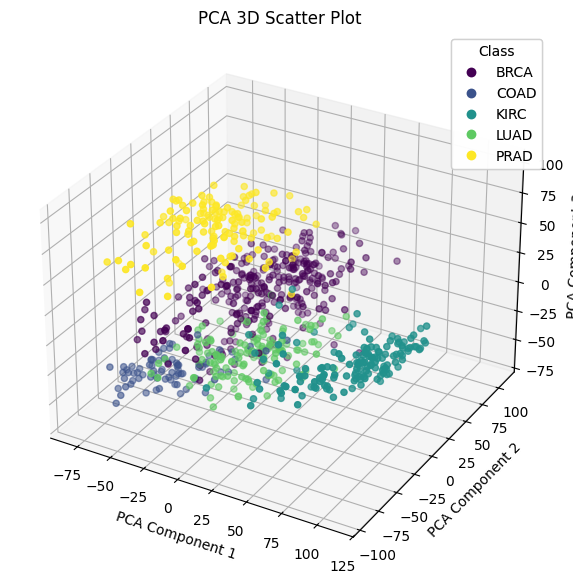

In [24]:
# Apply PCA to generate 3 principal components
pca = PCA(n_components=3)
pca_components = pca.fit_transform(gene_df_scaled)

# Plot the first three components
fig = px.scatter_3d(
    x=pca_components[:, 0],
    y=pca_components[:, 1],
    z=pca_components[:, 2],
    color=gene_df['Class'],
    title="PCA 3D Scatter Plot",
)


# Set labels
fig.update_layout(
    scene=dict(
        xaxis_title="PCA Component 1",
        yaxis_title="PCA Component 2",
        zaxis_title="PCA Component 3",
    )
)

# Show the plot
fig.show()

# Plot the first three components with labels as hue using Matplotlib
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    pca_components[:, 2],
    c=gene_df['Class'].astype('category').cat.codes,
    cmap='viridis'
)

# Set axis labels
ax.set_title("PCA 3D Scatter Plot")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

handles, _ = scatter.legend_elements()

# Create a legend
legend1 = ax.legend(handles, gene_df['Class'].astype(
    'category').cat.categories, title="Class")
ax.add_artist(legend1)

# Show the plot
plt.show()

In [25]:
# Variance covered by the first three components
explained_variance = pca.explained_variance_ratio_
print(f"Variance covered by the first three components: {explained_variance}")
print(
    f"Total variance covered by the first three components: {
        sum(explained_variance) * 100:.2f}%"
)

Variance covered by the first three components: [0.10590311 0.08665226 0.0792343 ]
Total variance covered by the first three components: 27.18%


Explained*variance_ratio* gives the percentage of variance explained by each of the selected components.

- Variance covered by the first three components: [0.10539781, 0.08754232, 0.07810081]
  - This means the first principal component explains 10.54% of the total variance, the second explains 8.75%, and the third explains 7.81%.
- Total variance covered by the first three components: 27.10%
  - This is calculated by summing the individual explained variances (0.27104094) and then converting it to a percentage by multiplying by 100 (27.10%).


In [26]:
# Apply KMeans on the original features
kmeans_original = KMeans(
    n_clusters=len(np.unique(gene_df["Class"])), random_state=random_state
)
kmeans_original_labels = kmeans_original.fit_predict(gene_df_scaled)

# Apply KMeans on the first three components returned by PCA
kmeans_pca = KMeans(n_clusters=len(
    np.unique(gene_df["Class"])), random_state=42)
kmeans_pca_labels = kmeans_pca.fit_predict(pca_components)


print(
    f"ARI Score for KMeans on original features: {
        adjusted_rand_score(gene_df["Class"], kmeans_original_labels)}"
)
print(
    f"ARI Score for KMeans on PCA components: {
        adjusted_rand_score(gene_df["Class"], kmeans_pca_labels)}"
)
print(f"Silhouette Score for KMeans on original features:: {silhouette_score(
    gene_df.drop(columns=["sample", "Class"]), kmeans_original_labels)}")
print(f"Silhouette Score for KMeans on PCA components: {
      silhouette_score(pca_components, kmeans_pca_labels)}")
print(f"Davies-Bouldin Score for KMeans on original features: {davies_bouldin_score(
    gene_df.drop(columns=["sample", "Class"]), kmeans_original_labels)}")
print(f"Davies-Bouldin Score for KMean on PCA components: {
      davies_bouldin_score(pca_components, kmeans_pca_labels)}")

ARI Score for KMeans on original features: 0.6110849745130496
ARI Score for KMeans on PCA components: 0.5667904874579236
Silhouette Score for KMeans on original features:: 0.1596030812848505
Silhouette Score for KMeans on PCA components: 0.38953297111510354
Davies-Bouldin Score for KMeans on original features: 2.541716345589285
Davies-Bouldin Score for KMean on PCA components: 0.9596757391647343


- Adjusted Rand Index (ARI): Clustering on the original features has a higher ARI, indicating better agreement with true labels.
- Silhouette Score: Clustering on the PCA components has a higher Silhouette Score, indicating better separation and cohesion of clusters.
- Davies-Bouldin Score: Clustering on the PCA components has a lower Davies-Bouldin Score, indicating more distinct and well-formed clusters.

Overall, while the clustering on the original features aligns better with the true labels (higher ARI), the clustering on the PCA components results in better-defined and more distinct clusters (higher Silhouette Score and lower Davies-Bouldin Score). This suggests that the PCA transformation helps in forming more cohesive and distinct clusters, even if they are slightly less aligned with the true labels.


# Summary

In this report we have learnt about the different clustering mechanism with different metrics that are required and dimension redction technique(PCA) that can used over data to make dataset ready for use purpose.
Here we have learnt about different libraries from python, sklearn from loading the file to the clustering/dimesion-reduction of the data.

# References

- https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition
- https://archive.ics.uci.edu/dataset/401/gene+expression+cancer+rna+seq
- Help of chatgpt for understanding the details and documentation
- Different blogs from https://medium.com/ like
  - https://medium.com/@castrojuan2810/unveiling-the-dynamics-of-k-means-and-dbscan-algorithms-3d5929f38d94
  - https://medium.com/@ioriopaolino62/clustering-approach-k-means-vs-dbscan-6d504c225f18
- https://scikit-learn.org/stable/api/sklearn.preprocessing.html
